In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import shutil
import random
import zipfile

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping

from PIL import Image, UnidentifiedImageError

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

In [2]:
def get_valid(file_path):
    
    correct_files = []
    
    for name in os.listdir(file_path):
        
        try:
            img = Image.open(file_path + "/" + name)
            correct_files.append(name)
            
        except UnidentifiedImageError:
            pass
            
    return correct_files


In [5]:
local_zip = 'kagglecatsanddogs_5340.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('tmp')
zip_ref.close()
classes = ['Cat', 'Dog']
original_cat_path = 'tmp/PetImages/Cat'
original_dog_path = 'tmp/PetImages/Dog'
original_cat = get_valid(original_cat_path)
original_dog = get_valid(original_dog_path)
random.seed(101)

random.shuffle(original_cat)
random.shuffle(original_dog)
size = min(len(original_cat), len(original_dog))
train_size = int(np.floor(0.7 * size))

valid_size = int(np.floor(0.2 * size))
test_size = size - train_size - valid_size
base_directory = 'dataset'
os.mkdir(base_directory)
type_datasets = ['train', 'valid', 'test']
directories = {}

for type_dataset in type_datasets:
    directory = os.path.join(base_directory, type_dataset)
    os.mkdir(directory)
    for name_class in classes:
        animal = os.path.join(directory, name_class)
        os.mkdir(animal)
        directories[f'{type_dataset}_{name_class}'] = animal+'/'
index = 0

for name_cat, name_dog in zip(original_cat, original_dog):
        if index <= train_size:
            type_of_dataset = 'train'
        elif train_size < index <= (train_size + valid_size):
            type_of_dataset = 'valid'
        elif (train_size + valid_size) < index <= (train_size + valid_size + test_size):
            type_of_dataset = 'test'
        shutil.copyfile(src=(original_cat_path + '/' +name_cat), dst=(directories[f'{type_of_dataset}_Cat']+name_cat))
        shutil.copyfile(src=(original_dog_path + '/' + name_dog), dst=(directories[f'{type_of_dataset}_Dog']+name_dog))
        index += 1

print(f'Dog - train: {len(os.listdir(directories["train_Dog"]))}\tCat - train: {len(os.listdir(directories["train_Cat"]))}')
print(f'Dog - valid: {len(os.listdir(directories["valid_Dog"]))}\tCat - valid: {len(os.listdir(directories["valid_Cat"]))}')
print(f'Dog - test:  {len(os.listdir(directories["test_Dog"]))}\tCat - test:  {len(os.listdir(directories["test_Cat"]))}')

Dog - train: 8750	Cat - train: 8750
Dog - valid: 2499	Cat - valid: 2499
Dog - test:  1250	Cat - test:  1250


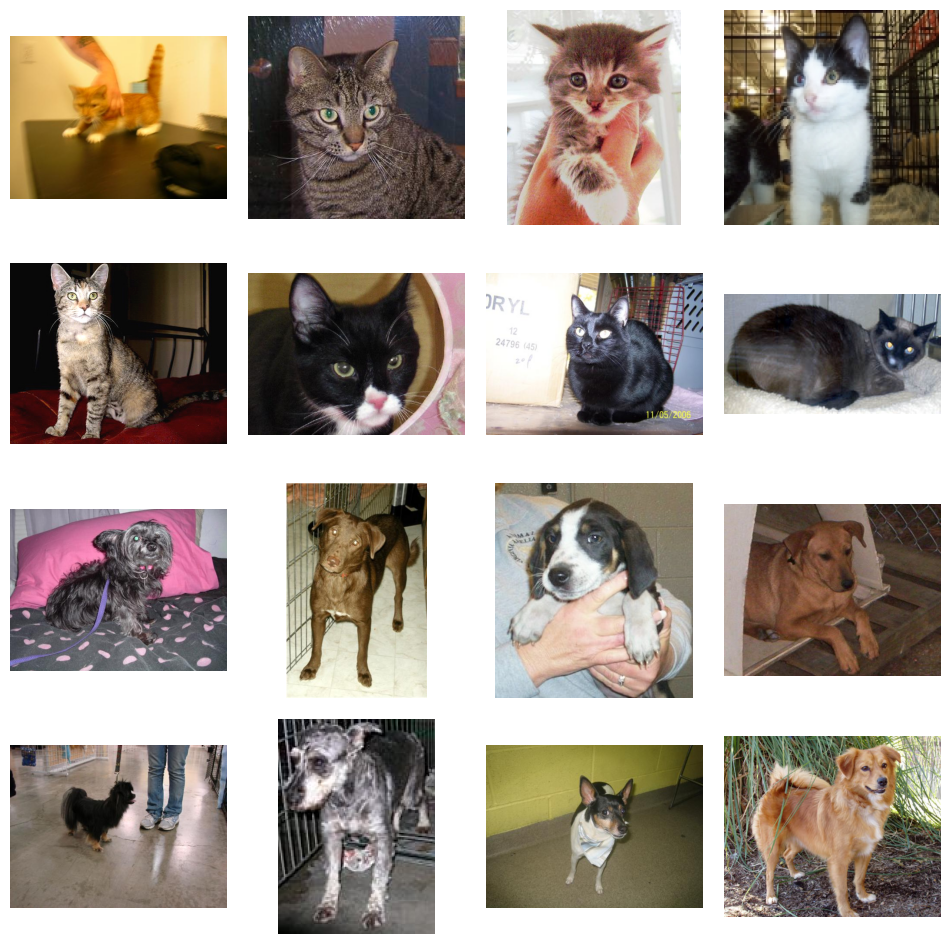

In [6]:
fig = plt.figure(figsize = (12, 12))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
for i, element in enumerate(os.listdir(os.path.join(directories["train_Cat"]))[:8]):
    ax = fig.add_subplot(4, 4, i+1)
    img = Image.open(directories["train_Cat"]+element)
    ax.imshow(img)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

for i, element in enumerate(os.listdir(os.path.join(directories["train_Dog"]))[:8]):
    ax = fig.add_subplot(4, 4, i+9)
    img = Image.open(directories["train_Dog"]+element)
    ax.imshow(img)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [30]:
img_width, img_height = 150, 150
train_data_dir = 'dataset/train/'
validation_data_dir = 'dataset/valid/'
epochs = 1000
batch_size = 64
steps_per_epoch = train_size // batch_size
validation_steps = valid_size // batch_size
patience = 5
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_data_dir,
                                                    target_size=(img_height, img_width),
                                                    batch_size=batch_size, class_mode='binary')
validation_generator = test_datagen.flow_from_directory(validation_data_dir,
     target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)
train_datagen_augmentation = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   rotation_range=30,
                                   horizontal_flip=True)
train_generator_augmentation = train_datagen_augmentation.flow_from_directory(train_data_dir,
                                                    target_size=(img_height, img_width),
                                                    batch_size=batch_size, class_mode='binary')

Found 17500 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Found 17500 images belonging to 2 classes.


In [8]:
models = []
os.mkdir("history")
os.mkdir("charts")

In [9]:
model_baseline = Sequential()

model_baseline.add(Flatten(input_shape=(150, 150, 3)))
model_baseline.add(Dense(units=1, activation='sigmoid'))
model_baseline.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(learning_rate=1e-4),
                       metrics=['accuracy'])
model_baseline.summary()
models.append("baseline")

C:\Users\jacek\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 67500)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │          67,501 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,501 (263.68 KB)

 Trainable params: 67,501 (263.68 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
es = EarlyStopping(patience=patience, monitor='val_accuracy', restore_best_weights=True)

In [11]:
history_baseline = model_baseline.fit(train_generator,
                                                steps_per_epoch=steps_per_epoch,
                                                epochs=epochs,
                                                validation_data=validation_generator,
                                                validation_steps=validation_steps,
                                                callbacks=[es])
history_baseline_df = pd.DataFrame(history_baseline.history)
history_baseline_csv_file = 'history/history_baseline.csv'

with open(history_baseline_csv_file, mode='w') as f:
    history_baseline_df.to_csv(f)

Epoch 1/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step - accuracy: 0.5021 - loss: 1.0020 - val_accuracy: 0.5072 - val_loss: 0.7841
Epoch 2/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - accuracy: 0.5232 - loss: 0.9221 - val_accuracy: 0.4952 - val_loss: 1.4314
Epoch 3/1000
  2/136 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.5586 - loss: 1.1760

C:\Users\jacek\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5547 - loss: 1.0600 - val_accuracy: 0.5072 - val_loss: 0.9394
Epoch 4/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 21s 156ms/step - accuracy: 0.5174 - loss: 0.9296 - val_accuracy: 0.5160 - val_loss: 0.8010
Epoch 5/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 29s 213ms/step - accuracy: 0.5213 - loss: 0.9218 - val_accuracy: 0.5220 - val_loss: 0.8670
Epoch 6/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.4688 - loss: 1.0355 - val_accuracy: 0.5184 - val_loss: 0.8409
Epoch 7/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 24s 173ms/step - accuracy: 0.5281 - loss: 0.9191 - val_accuracy: 0.5156 - val_loss: 0.9352
Epoch 8/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 31s 228ms/step - accuracy: 0.5216 - loss: 0.9200 - val_accuracy: 0.4952 - val_loss: 1.0687
Epoch 9/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.4219 - loss: 1.0509 - val_accuracy: 0.5148 - val_loss: 1.1721
Epoch 10/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 41s 303ms/step - accuracy: 0.5403 - loss: 0.8

In [13]:
model_simple_1 = Sequential()
model_simple_1.add(Conv2D(filters=10, kernel_size=(3, 3), activation='relu', input_shape=(150, 150, 3)))
model_simple_1.add(MaxPooling2D(2, 2))
model_simple_1.add(Flatten())
model_simple_1.add(Dense(units=1, activation='sigmoid'))
model_simple_1.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])
model_simple_1.summary()
models.append("simple_1")

C:\Users\jacek\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 10)        │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 54760)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │          54,761 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 55,041 (215.00 KB)

 Trainable params: 55,041 (215.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_simple_1 = model_simple_1.fit(train_generator,
                                                steps_per_epoch=steps_per_epoch,
                                                epochs=epochs,
                                                validation_data=validation_generator,
                                                validation_steps=validation_steps,
                                                callbacks=[es])

history_simple_1_df = pd.DataFrame(history_simple_1.history)
history_simple_1_csv_file = 'history/history_simple_1.csv'

with open(history_simple_1_csv_file, mode='w') as f:
    history_simple_1_df.to_csv(f)

Epoch 1/1000
129/136 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.5577 - loss: 0.7896

C:\Users\jacek\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


136/136 ━━━━━━━━━━━━━━━━━━━━ 22s 153ms/step - accuracy: 0.5930 - loss: 0.6920 - val_accuracy: 0.6526 - val_loss: 0.6136
Epoch 2/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 24s 175ms/step - accuracy: 0.6906 - loss: 0.5826 - val_accuracy: 0.6935 - val_loss: 0.5861
Epoch 3/1000
  1/136 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.6875 - loss: 0.5748

C:\Users\jacek\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


136/136 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6797 - loss: 0.5852 - val_accuracy: 0.7103 - val_loss: 0.5779
Epoch 4/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - accuracy: 0.7395 - loss: 0.5221 - val_accuracy: 0.7063 - val_loss: 0.5720
Epoch 5/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 20s 146ms/step - accuracy: 0.7661 - loss: 0.4921 - val_accuracy: 0.7292 - val_loss: 0.5394
Epoch 6/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 0.7826 - loss: 0.4699 - val_accuracy: 0.7179 - val_loss: 0.5560
Epoch 7/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 35s 259ms/step - accuracy: 0.7889 - loss: 0.4557 - val_accuracy: 0.7220 - val_loss: 0.5396
Epoch 8/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 33s 240ms/step - accuracy: 0.8080 - loss: 0.4276 - val_accuracy: 0.7272 - val_loss: 0.5416
Epoch 9/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.8281 - loss: 0.4305 - val_accuracy: 0.7260 - val_loss: 0.5391
Epoch 10/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 32s 232ms/step - accuracy: 0.8218 - loss: 0.4

In [15]:
model_simple_2 = Sequential()
model_simple_2.add(Conv2D(filters=10, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(150, 150, 3)))
model_simple_2.add(MaxPooling2D(2, 2))
model_simple_2.add(Flatten())
model_simple_2.add(Dense(units=1, activation='sigmoid'))
model_simple_2.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])
model_simple_2.summary()
models.append("simple_2")

C:\Users\jacek\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)                    │ (None, 150, 150, 10)        │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 75, 75, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 56250)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │          56,251 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,531 (220.82 KB)

 Trainable params: 56,531 (220.82 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_simple_2 = model_simple_2.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[es]
)

history_simple_2_df = pd.DataFrame(history_simple_2.history)

history_simple_2_csv_file = 'history/history_simple_2.csv'

with open(history_simple_2_csv_file, mode='w') as f:
    history_simple_2_df.to_csv(f)

Epoch 1/1000
 36/274 ━━━━━━━━━━━━━━━━━━━━ 33s 142ms/step - accuracy: 0.5302 - loss: 1.2046

C:\Users\jacek\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


274/274 ━━━━━━━━━━━━━━━━━━━━ 60s 213ms/step - accuracy: 0.6277 - loss: 0.6731 - val_accuracy: 0.6675 - val_loss: 0.6161
Epoch 2/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 58s 210ms/step - accuracy: 0.7003 - loss: 0.5765 - val_accuracy: 0.6625 - val_loss: 0.6132
Epoch 3/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 55s 202ms/step - accuracy: 0.7412 - loss: 0.5216 - val_accuracy: 0.7013 - val_loss: 0.5825
Epoch 4/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 56s 205ms/step - accuracy: 0.7717 - loss: 0.4776 - val_accuracy: 0.7185 - val_loss: 0.5714
Epoch 5/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 65s 237ms/step - accuracy: 0.7957 - loss: 0.4452 - val_accuracy: 0.7097 - val_loss: 0.5842


In [17]:
model_1 = Sequential()

# Block 1
model_1.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_1.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_1.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_1.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_1.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Flatten())
model_1.add(Dense(256, activation='relu'))
model_1.add(Dense(128, activation='relu'))
model_1.add(Dense(units=1, activation='sigmoid'))
model_1.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)
model_1.summary()
models.append("model_1")

C:\Users\jacek\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 150, 150, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 150, 150, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 75, 75, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 75, 75, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 37, 37, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 37, 37, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 37, 37, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 18, 18, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 18, 18, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 18, 18, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 10368)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │       2,654,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,981,009 (11.37 MB)

 Trainable params: 2,981,009 (11.37 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_model_1 = model_1.fit(train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[es]
)

history_model_1_df = pd.DataFrame(history_model_1.history)

history_model_1_csv_file = 'history/history_model_1.csv'

with open(history_model_1_csv_file, mode='w') as f:
    history_model_1_df.to_csv(f)

Epoch 1/1000
155/274 ━━━━━━━━━━━━━━━━━━━━ 1:03 537ms/step - accuracy: 0.5138 - loss: 0.6920

C:\Users\jacek\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


274/274 ━━━━━━━━━━━━━━━━━━━━ 148s 533ms/step - accuracy: 0.5492 - loss: 0.6840 - val_accuracy: 0.5848 - val_loss: 0.6621
Epoch 2/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 150s 546ms/step - accuracy: 0.6411 - loss: 0.6272 - val_accuracy: 0.7055 - val_loss: 0.5618
Epoch 3/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 127s 463ms/step - accuracy: 0.7092 - loss: 0.5578 - val_accuracy: 0.7075 - val_loss: 0.5624
Epoch 4/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 212s 719ms/step - accuracy: 0.7342 - loss: 0.5255 - val_accuracy: 0.7447 - val_loss: 0.5153
Epoch 5/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 143s 520ms/step - accuracy: 0.7559 - loss: 0.4994 - val_accuracy: 0.7477 - val_loss: 0.5047
Epoch 6/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 127s 463ms/step - accuracy: 0.7708 - loss: 0.4757 - val_accuracy: 0.7605 - val_loss: 0.4970
Epoch 7/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 92s 333ms/step - accuracy: 0.7854 - loss: 0.4551 - val_accuracy: 0.7709 - val_loss: 0.4790
Epoch 8/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 88s 321ms/step - accuracy: 0.8038 

In [19]:
model_2 = Sequential()

# Block 1
model_2.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_2.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))
model_2.add(Flatten())
model_2.add(Dropout(0.5))
model_2.add(Dense(256, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dense(units=1, activation='sigmoid'))
model_2.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)
model_2.summary()
models.append("model_2")

C:\Users\jacek\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)                   │ (None, 150, 150, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 150, 150, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 75, 75, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 75, 75, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 37, 37, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 37, 37, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 37, 37, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 18, 18, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 18, 18, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 18, 18, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 10368)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10368)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       2,654,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,981,009 (11.37 MB)

 Trainable params: 2,981,009 (11.37 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history_model_2 = model_2.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[es]
)

history_model_2_df = pd.DataFrame(history_model_2.history)

history_model_2_csv_file = 'history/history_model_2.csv'

with open(history_model_2_csv_file, mode='w') as f:
    history_model_2_df.to_csv(f)

Epoch 1/1000
 67/274 ━━━━━━━━━━━━━━━━━━━━ 44s 214ms/step - accuracy: 0.5132 - loss: 0.6928

C:\Users\jacek\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


274/274 ━━━━━━━━━━━━━━━━━━━━ 69s 250ms/step - accuracy: 0.5624 - loss: 0.6704 - val_accuracy: 0.6218 - val_loss: 0.6426
Epoch 2/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 65s 236ms/step - accuracy: 0.6258 - loss: 0.6303 - val_accuracy: 0.6599 - val_loss: 0.6039
Epoch 3/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 80s 290ms/step - accuracy: 0.6711 - loss: 0.5902 - val_accuracy: 0.7163 - val_loss: 0.5523
Epoch 4/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 73s 265ms/step - accuracy: 0.7106 - loss: 0.5564 - val_accuracy: 0.7297 - val_loss: 0.5363
Epoch 5/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 66s 241ms/step - accuracy: 0.7223 - loss: 0.5383 - val_accuracy: 0.7377 - val_loss: 0.5259


In [21]:
model_3 = Sequential()

# Block 1
model_3.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_3.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_3.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_3.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_3.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D(pool_size=(2, 2)))
model_3.add(Flatten())
model_3.add(Dropout(0.5))
model_3.add(Dense(256, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(128, activation='relu'))
model_3.add(Dense(units=1, activation='sigmoid'))
model_3.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)
model_3.summary()
models.append("model_3")

C:\Users\jacek\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 150, 150, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 150, 150, 16)        │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_20 (Conv2D)                   │ (None, 75, 75, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_21 (Conv2D)                   │ (None, 75, 75, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 37, 37, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_22 (Conv2D)                   │ (None, 37, 37, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_23 (Conv2D)                   │ (None, 37, 37, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 18, 18, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (None, 18, 18, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (None, 18, 18, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 9, 9, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 10368)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10368)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 256)                 │       2,654,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,981,009 (11.37 MB)

 Trainable params: 2,981,009 (11.37 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_model_3 = model_3.fit(train_generator_augmentation,
                                        steps_per_epoch=steps_per_epoch,
                                        epochs=epochs,
                                        validation_data=validation_generator,
                                        validation_steps=validation_steps,
                                        callbacks=[es])

history_model_3_df = pd.DataFrame(history_model_3.history)
history_model_3_csv_file = 'history/history_model_3.csv'
with open(history_model_3_csv_file, mode='w') as f:
    history_model_3_df.to_csv(f)

Epoch 1/1000
  9/136 ━━━━━━━━━━━━━━━━━━━━ 40s 321ms/step - accuracy: 0.5279 - loss: 0.6931

C:\Users\jacek\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


136/136 ━━━━━━━━━━━━━━━━━━━━ 55s 393ms/step - accuracy: 0.5071 - loss: 0.6920 - val_accuracy: 0.4996 - val_loss: 0.6885
Epoch 2/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 83s 617ms/step - accuracy: 0.5591 - loss: 0.6761 - val_accuracy: 0.6066 - val_loss: 0.6466
Epoch 3/1000
  2/136 ━━━━━━━━━━━━━━━━━━━━ 50s 381ms/step - accuracy: 0.5586 - loss: 0.6535

C:\Users\jacek\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


136/136 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.5859 - loss: 0.6455 - val_accuracy: 0.5950 - val_loss: 0.6608
Epoch 4/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 59s 429ms/step - accuracy: 0.6037 - loss: 0.6544 - val_accuracy: 0.6254 - val_loss: 0.6343
Epoch 5/1000
136/136 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step - accuracy: 0.6095 - loss: 0.6421 - val_accuracy: 0.6526 - val_loss: 0.6195


In [23]:
from tensorflow.keras.applications import VGG16

vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
vgg16.trainable = True

set_trainable = False
for layer in vgg16.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in vgg16.layers:
    print(f'layer_name: {layer.name:13} trainable: {layer.trainable}')

model_4 = Sequential()
model_4.add(vgg16)
model_4.add(Flatten())
model_4.add(Dropout(0.5))
model_4.add(Dense(256, activation='relu'))
model_4.add(Dropout(0.5))
model_4.add(Dense(128, activation='relu'))
model_4.add(Dense(units=1, activation='sigmoid'))
model_4.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)
model_4.summary()
models.append("model_4")

layer_name: input_layer_6 trainable: False
layer_name: block1_conv1  trainable: False
layer_name: block1_conv2  trainable: False
layer_name: block1_pool   trainable: False
layer_name: block2_conv1  trainable: False
layer_name: block2_conv2  trainable: False
layer_name: block2_pool   trainable: False
layer_name: block3_conv1  trainable: False
layer_name: block3_conv2  trainable: False
layer_name: block3_conv3  trainable: False
layer_name: block3_pool   trainable: False
layer_name: block4_conv1  trainable: False
layer_name: block4_conv2  trainable: False
layer_name: block4_conv3  trainable: False
layer_name: block4_pool   trainable: False
layer_name: block5_conv1  trainable: True
layer_name: block5_conv2  trainable: True
layer_name: block5_conv3  trainable: True
layer_name: block5_pool   trainable: True


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 4, 4, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,845,121 (64.26 MB)

 Trainable params: 9,209,857 (35.13 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [24]:
history_model_4 = model_4.fit(
    train_generator_augmentation,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[es]
)

history_model_4_df = pd.DataFrame(history_model_4.history)

history_model_4_csv_file = 'history/history_model_4.csv'

with open(history_model_4_csv_file, mode='w') as f:
    history_model_4_df.to_csv(f) 

Epoch 1/1000
173/274 ━━━━━━━━━━━━━━━━━━━━ 2:20 1s/step - accuracy: 0.7302 - loss: 0.5223

C:\Users\jacek\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


274/274 ━━━━━━━━━━━━━━━━━━━━ 463s 2s/step - accuracy: 0.8422 - loss: 0.3457 - val_accuracy: 0.9362 - val_loss: 0.1859
Epoch 2/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 453s 2s/step - accuracy: 0.9114 - loss: 0.2118 - val_accuracy: 0.9438 - val_loss: 0.1537
Epoch 3/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 420s 2s/step - accuracy: 0.9264 - loss: 0.1816 - val_accuracy: 0.9564 - val_loss: 0.1266
Epoch 4/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 422s 2s/step - accuracy: 0.9367 - loss: 0.1563 - val_accuracy: 0.9560 - val_loss: 0.1295
Epoch 5/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 462s 2s/step - accuracy: 0.9428 - loss: 0.1409 - val_accuracy: 0.9628 - val_loss: 0.1233
Epoch 6/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 474s 2s/step - accuracy: 0.9497 - loss: 0.1284 - val_accuracy: 0.9622 - val_loss: 0.1192
Epoch 7/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - accuracy: 0.9551 - loss: 0.1158 - val_accuracy: 0.9634 - val_loss: 0.1233
Epoch 8/1000
274/274 ━━━━━━━━━━━━━━━━━━━━ 636s 2s/step - accuracy: 0.9577 - loss: 0.1075 - val_a

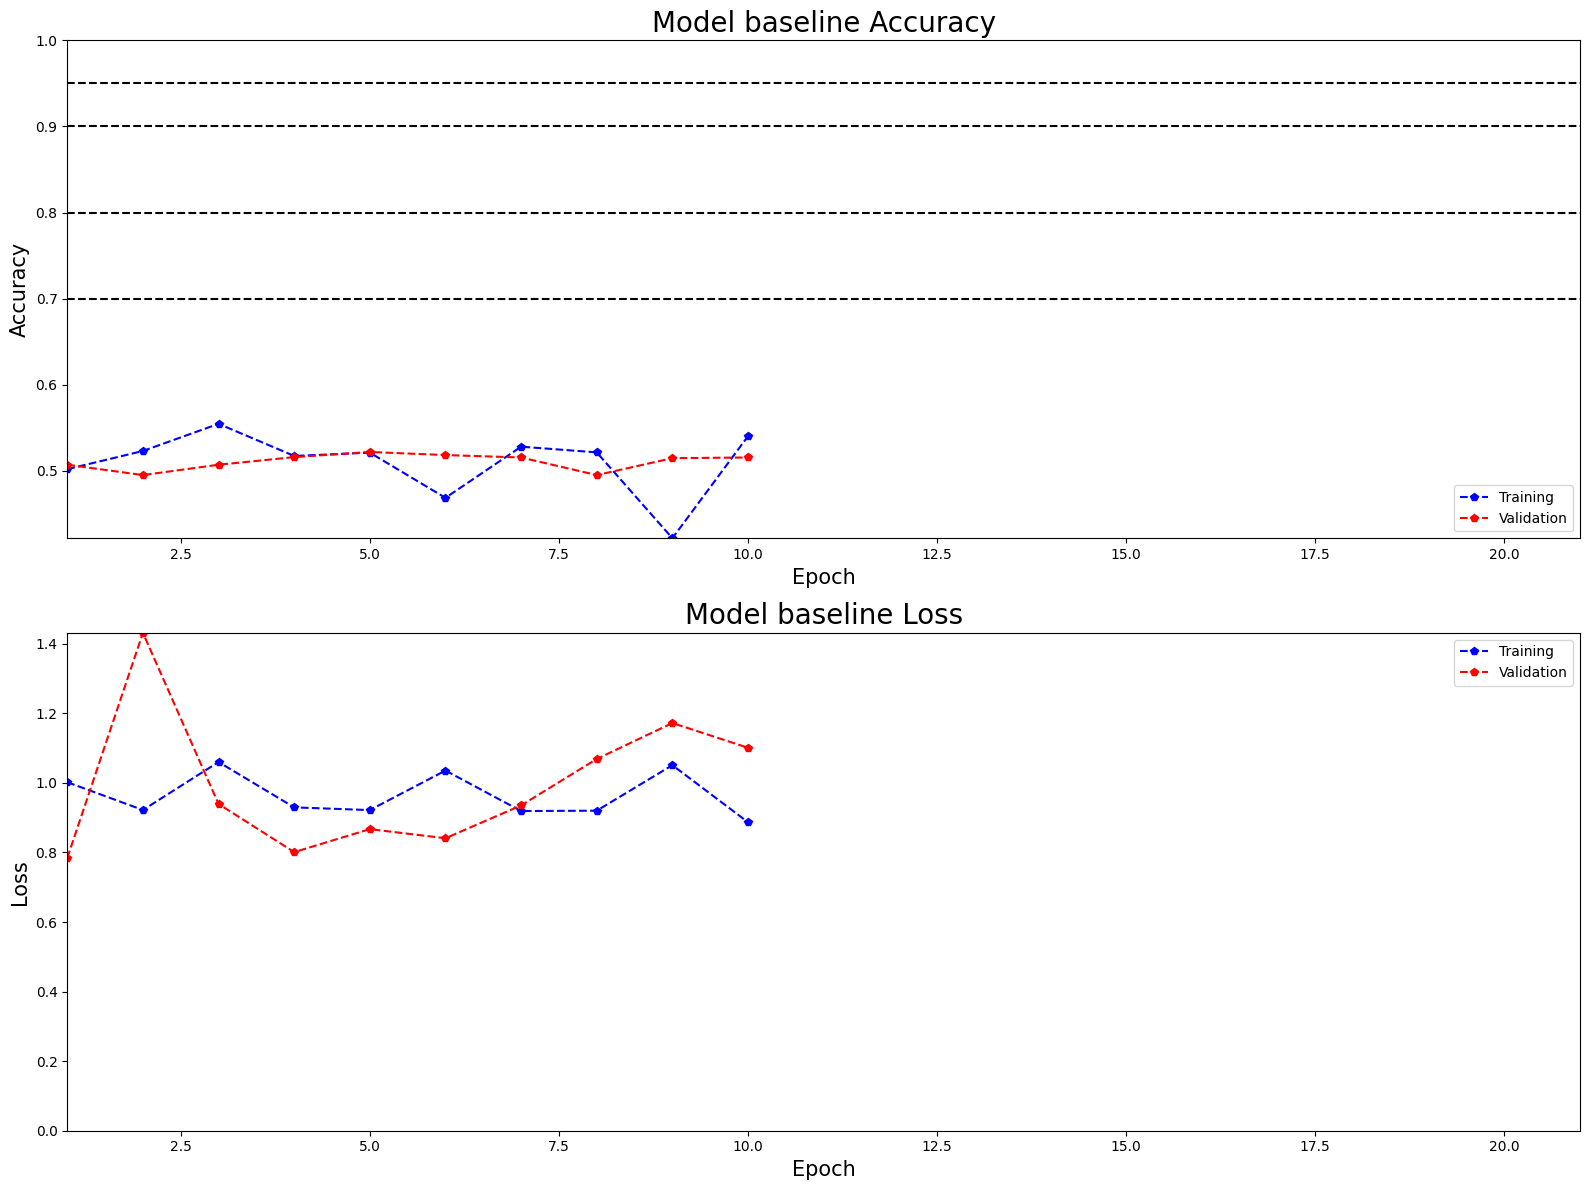

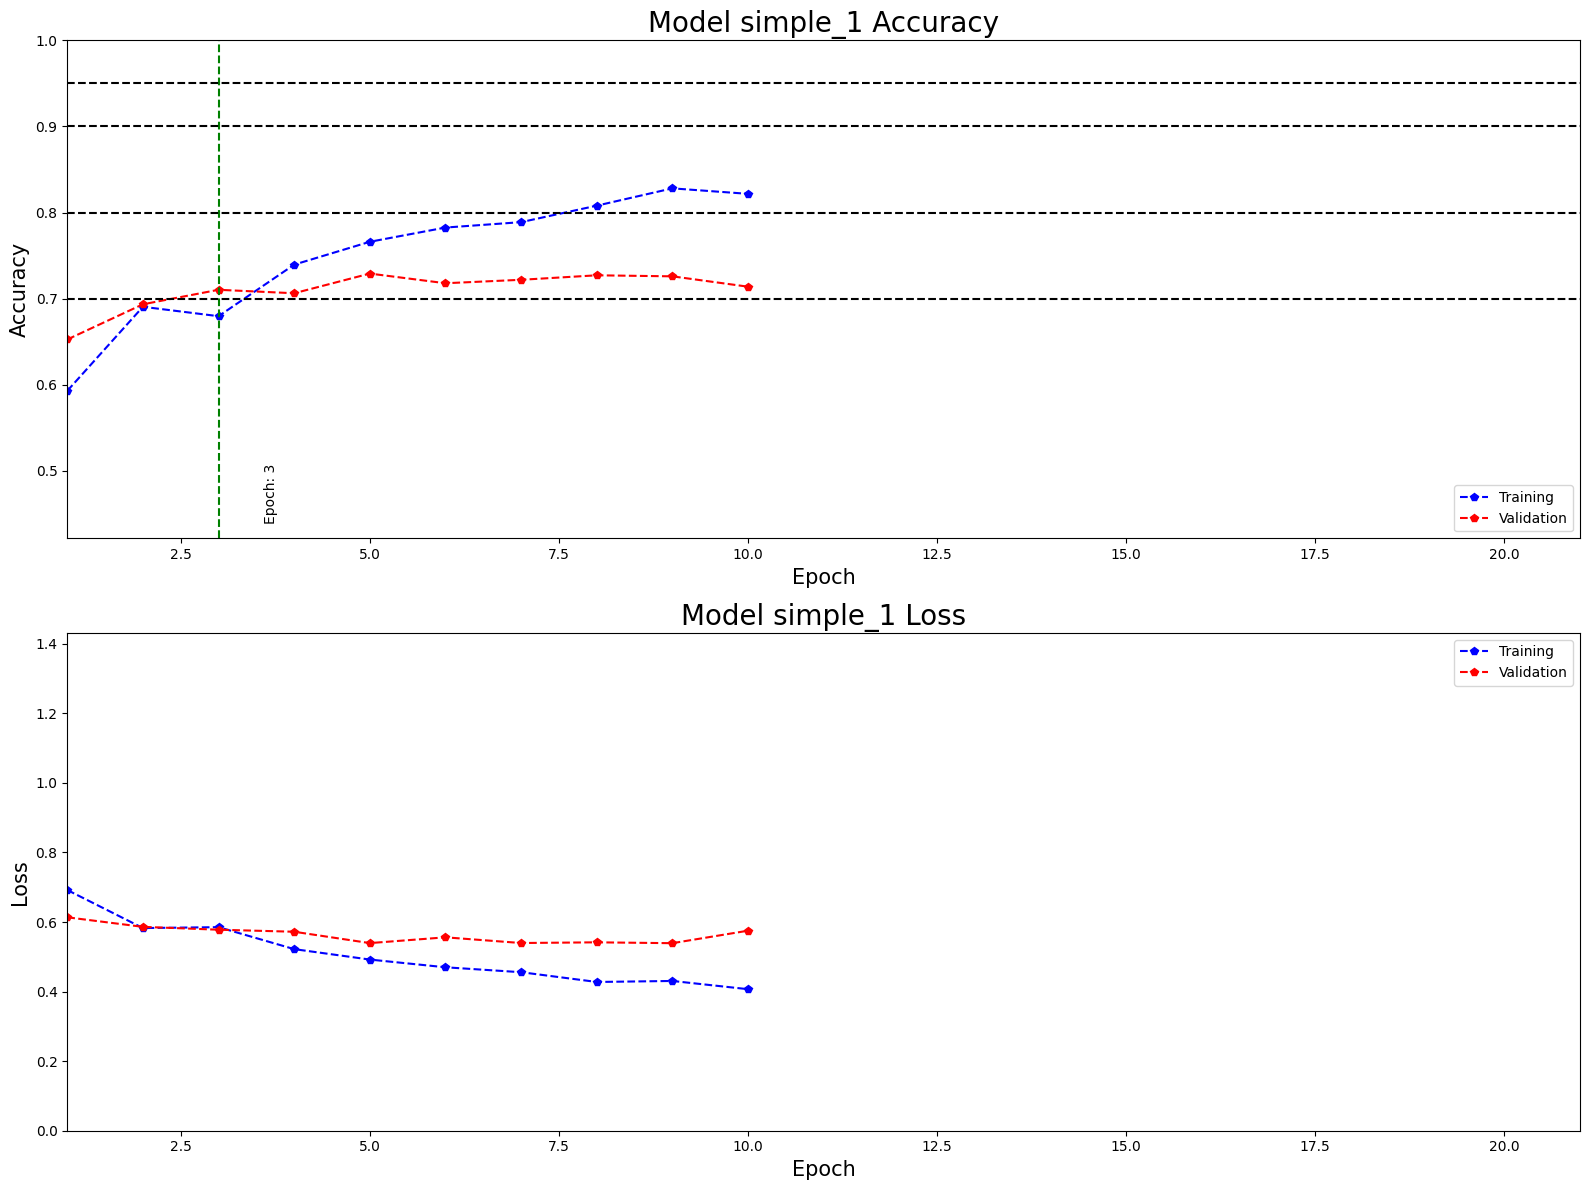

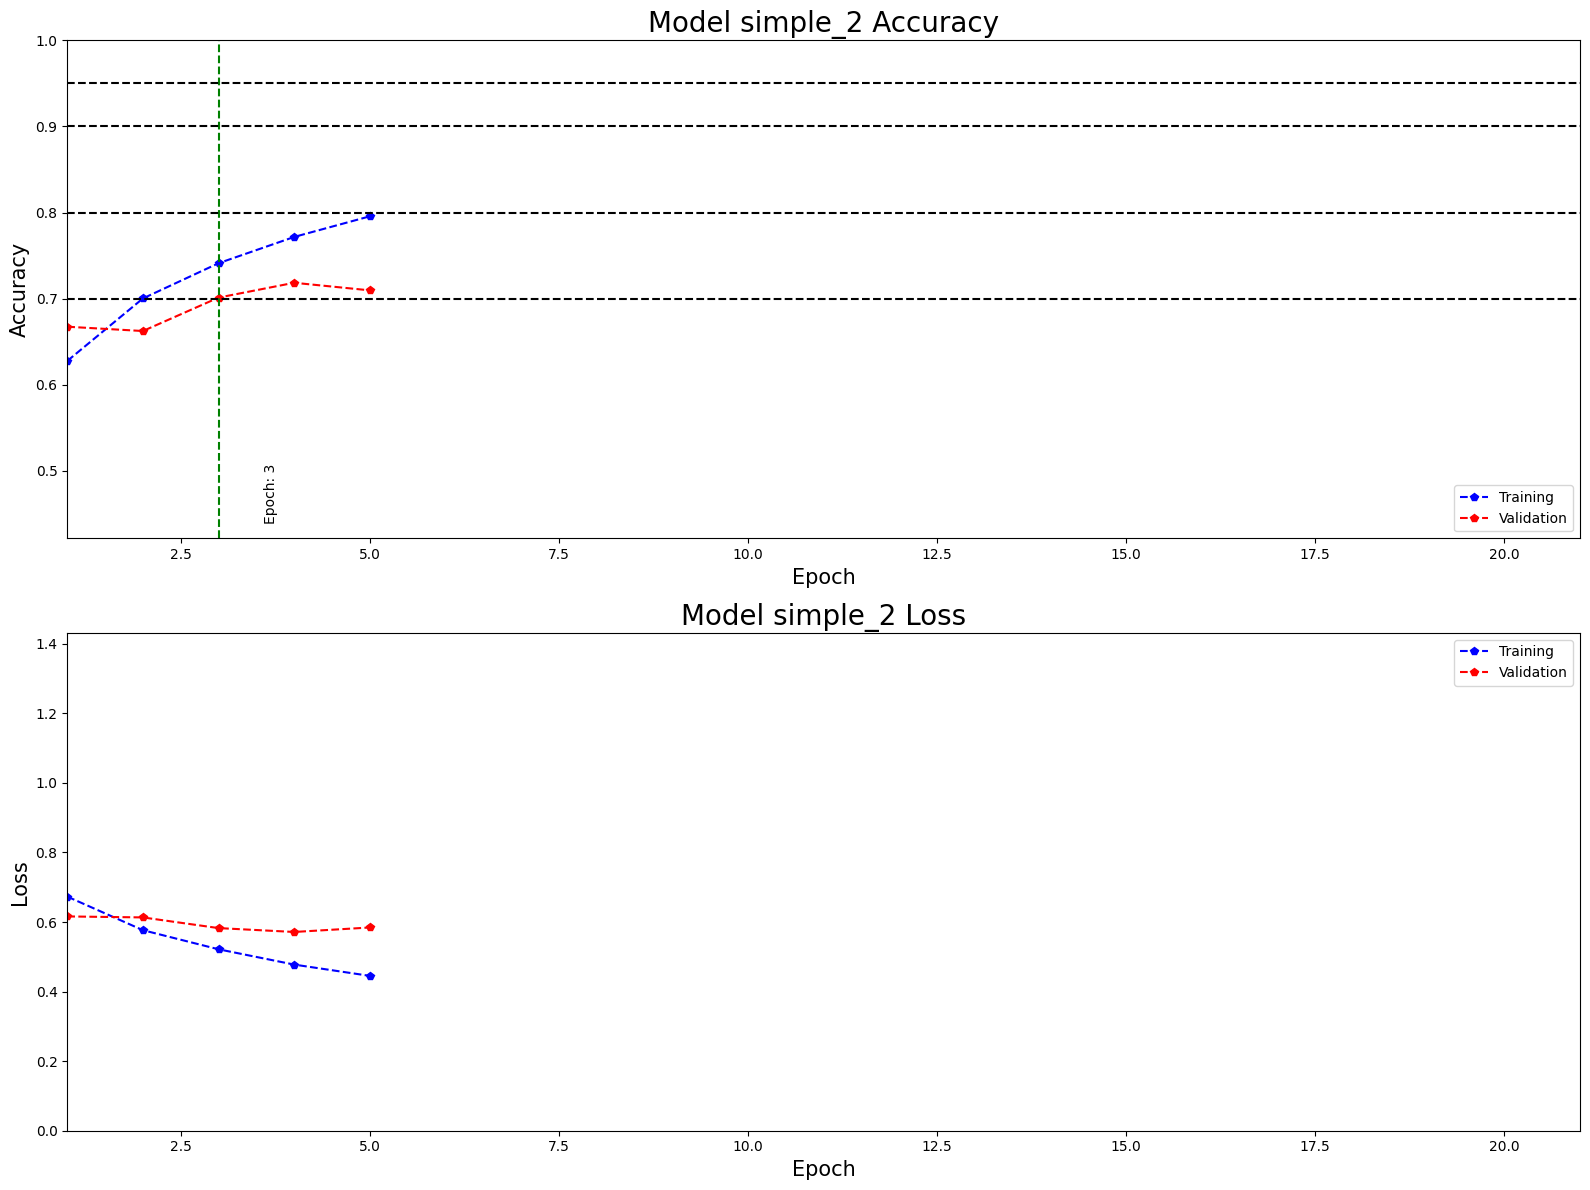

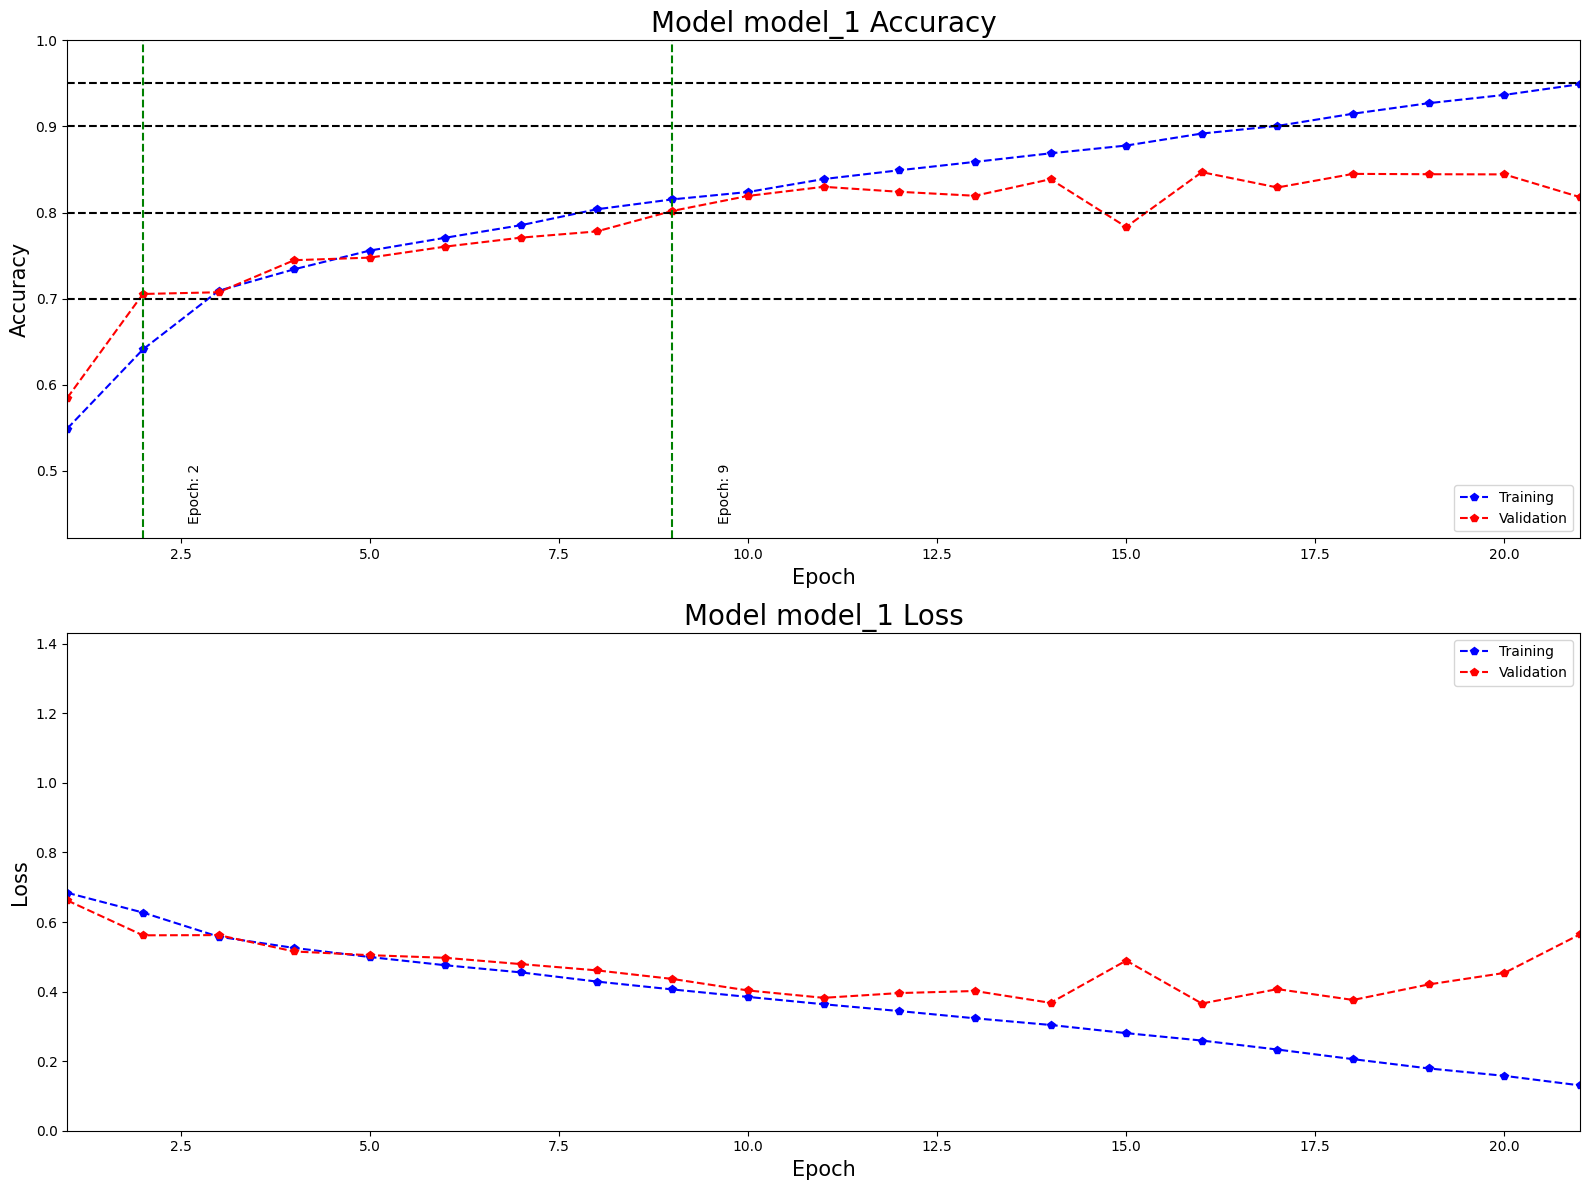

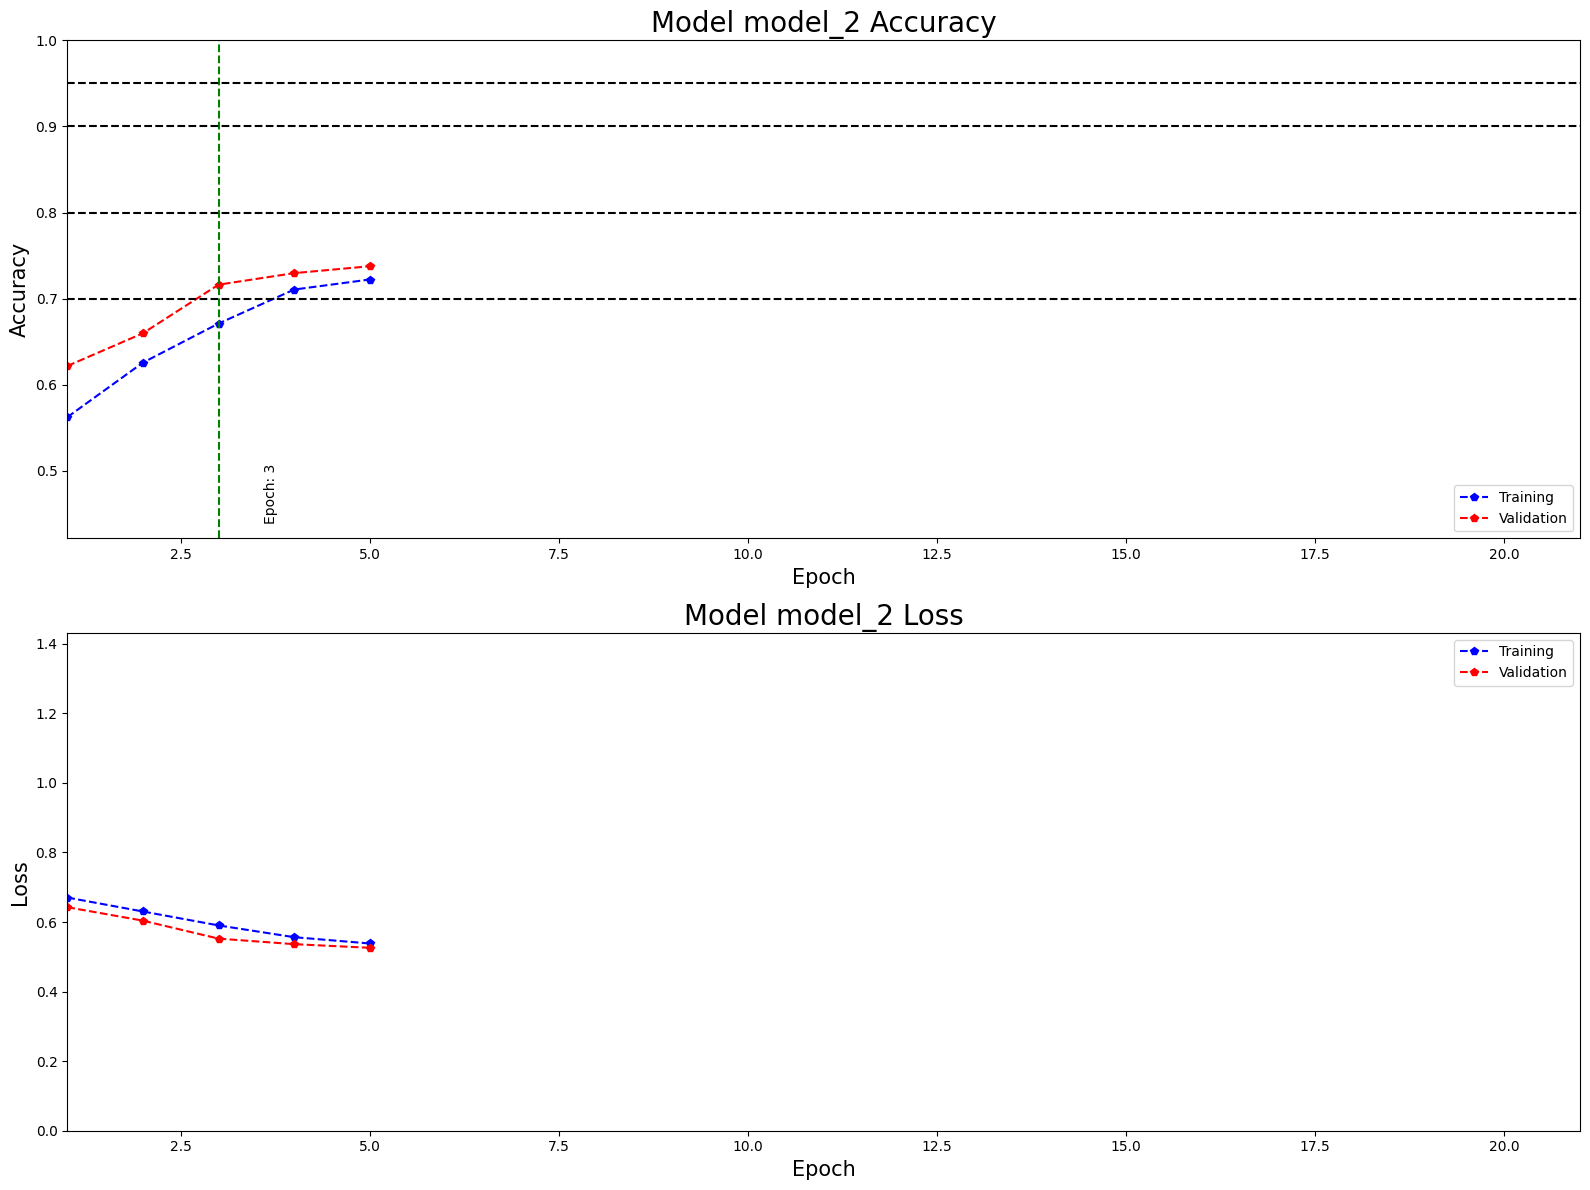

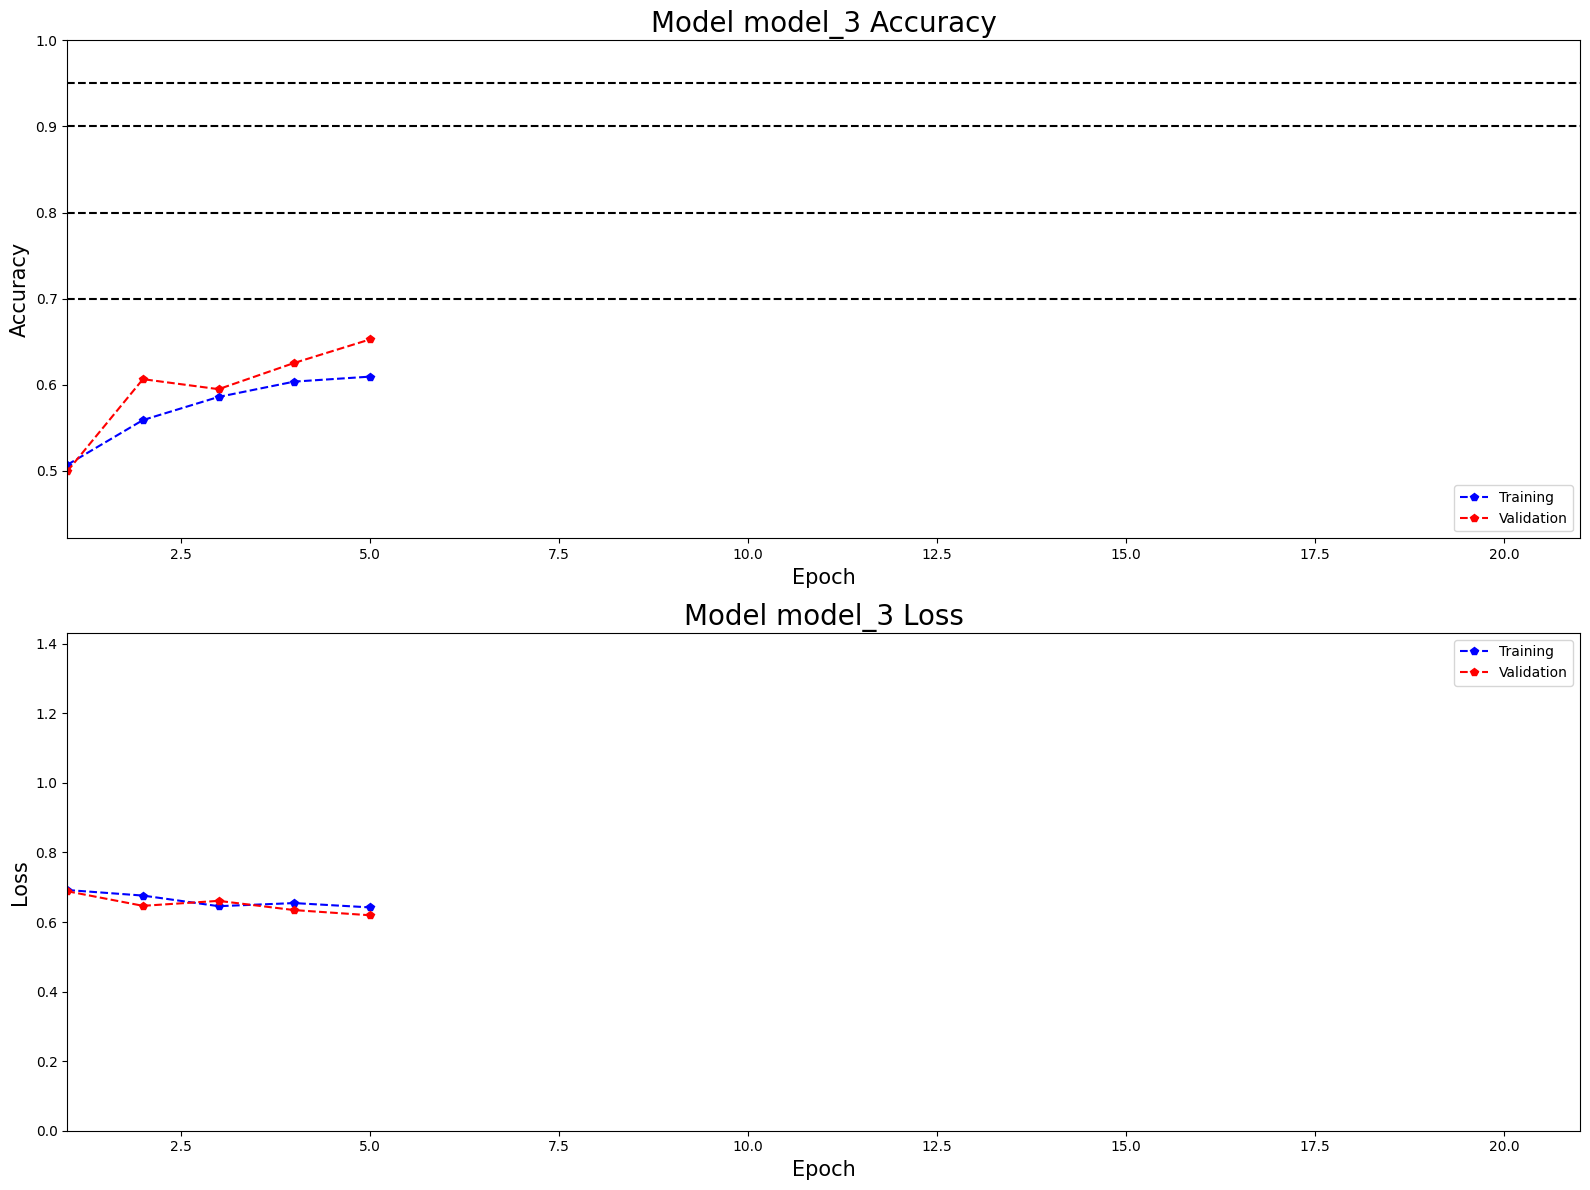

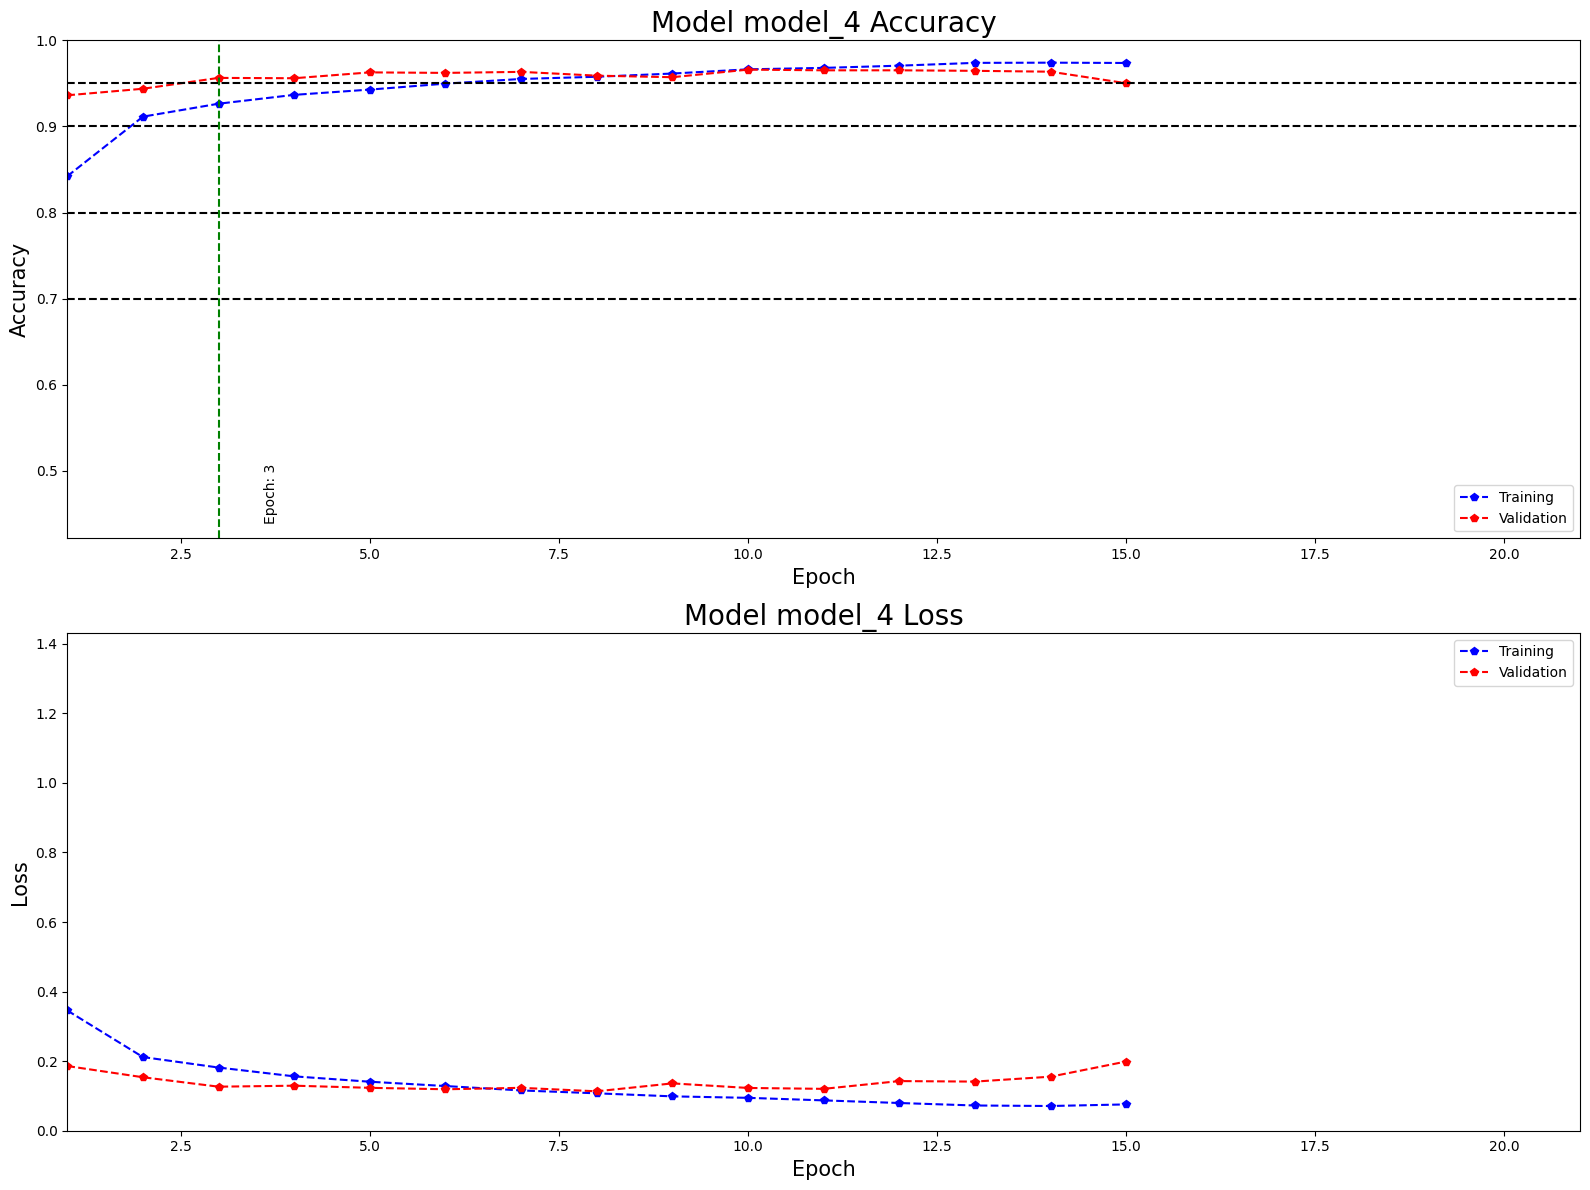

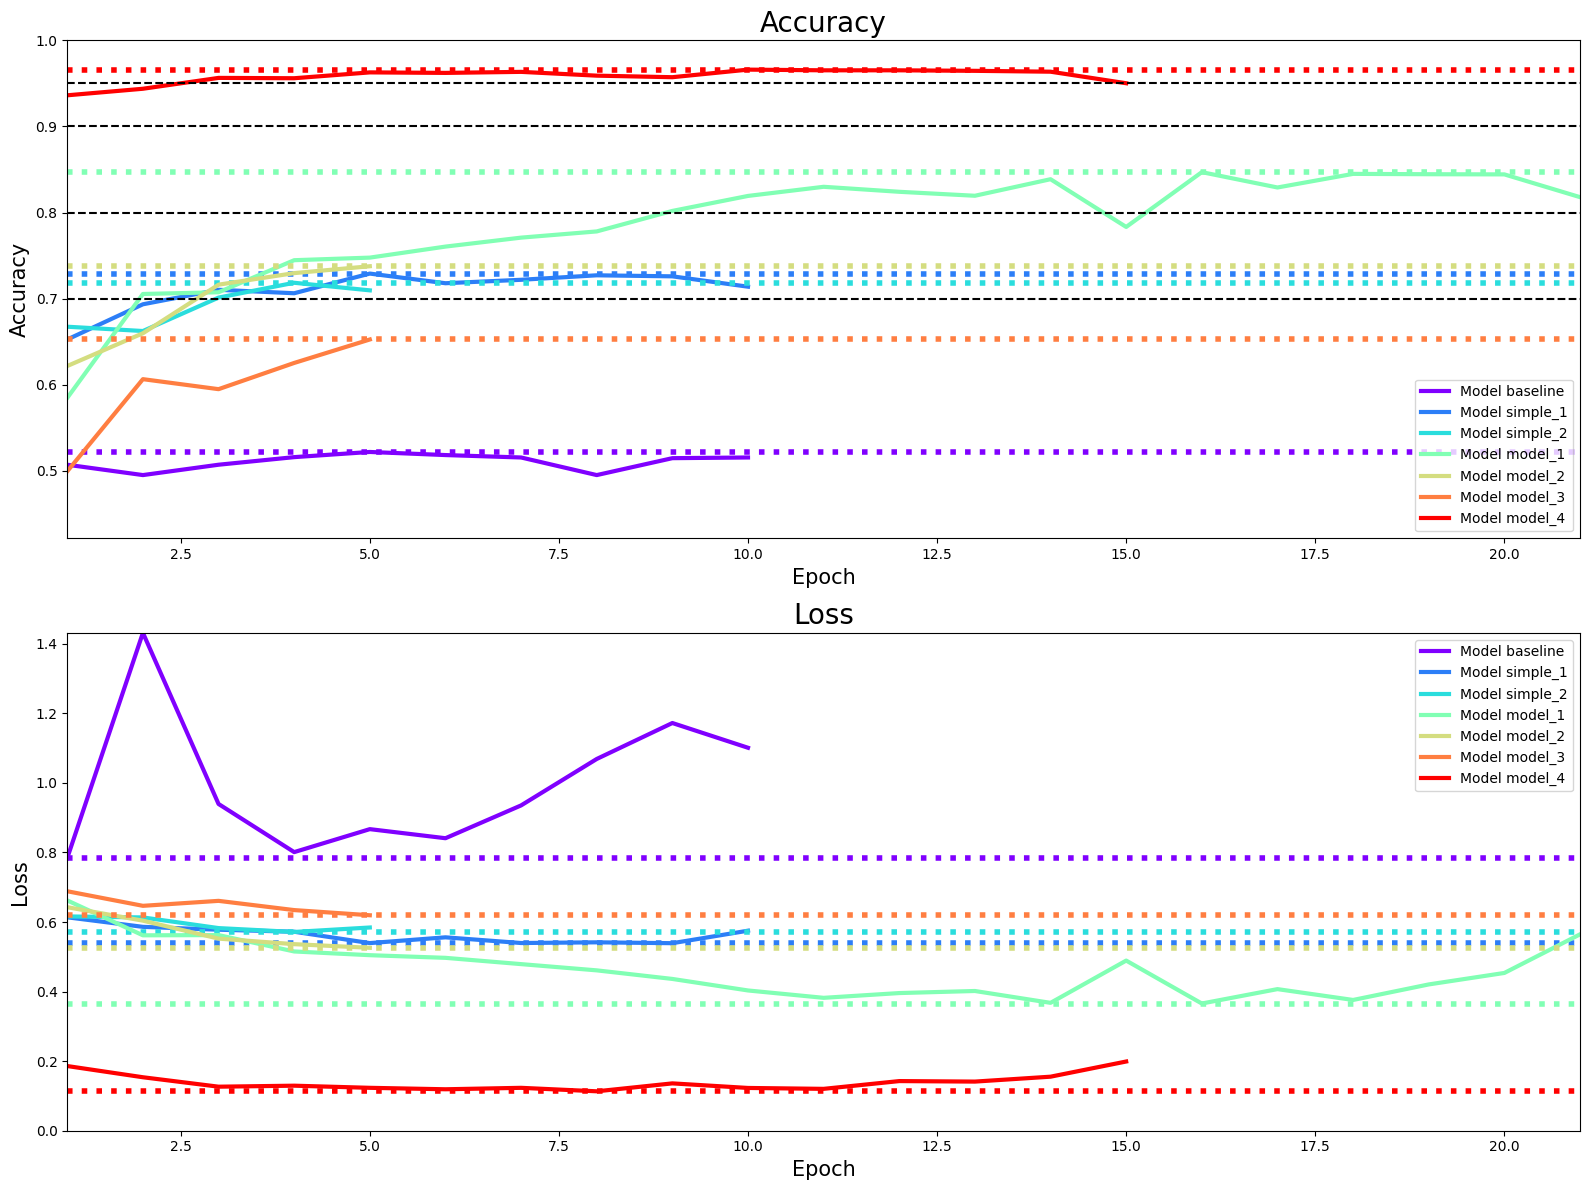

In [32]:
max_index = 0
min_accuracy = 1
max_loss = 0
colors = plt.cm.rainbow(np.linspace(0, 1, len(models)))

for model in models:
    df = pd.read_csv(f'history/history_{model}.csv', index_col=0)
    df.index += 1
    if max_index < max(df.index):
        max_index = max(df.index)
    if min_accuracy > min(df[['accuracy', 'val_accuracy']].min()):
        min_accuracy = min(df[['accuracy', 'val_accuracy']].min())
    if max_loss < max(df[['loss', 'val_loss']].max()):
        max_loss = max(df[['loss', 'val_loss']].max())

for model in models:
    df = pd.read_csv(f'history/history_{model}.csv', index_col=0)
    df.index += 1
    fig = plt.figure(figsize=(16,12))
    ax = fig.add_subplot(211)
    ax.plot(df['accuracy'], "bp--")
    ax.plot(df['val_accuracy'], "rp--")
    ax.set_title(f'Model {model} Accuracy', fontsize=20)
    ax.set_ylabel('Accuracy', fontsize=15)
    ax.set_xlabel('Epoch', fontsize=15)
    ax.set_xlim([1, max_index])
    ax.set_ylim([min_accuracy, 1])

    for milestone in (0.7, 0.8, 0.9, 0.95):
        ax.axhline(milestone, color="k", linestyle="--")
        try:
            if min(df[df['val_accuracy'] >= milestone].index) > 1:
                plt.axvline(min(df[df['val_accuracy'] >= milestone].index), color="g", linestyle="--")
                ax.text(min(df[df['val_accuracy'] >= milestone].index)+0.6, min_accuracy+0.02,
                        f'Epoch: {min(df[df["val_accuracy"] >= milestone].index)}', rotation=90)
        except:
            pass

    plt.legend(['Training', 'Validation'], loc='lower right')
    ax = fig.add_subplot(212)
    ax.plot(df['loss'], "bp--")
    ax.plot(df['val_loss'], "rp--")
    ax.set_title(f'Model {model} Loss', fontsize=20)
    ax.set_ylabel('Loss', fontsize=15)
    ax.set_xlabel('Epoch', fontsize=15)
    ax.set_xlim([1, max_index])
    ax.set_ylim([0, max_loss])
    ax.legend(['Training', 'Validation'], loc='upper right')
    plt.tight_layout()
    plt.savefig(f'charts/train_history_{model}.png', transparent=True, dpi=600)
    plt.show()

fig = plt.figure(figsize=(16,12))
ax = fig.add_subplot(211)
for model, color in zip(models, colors):
    df = pd.read_csv(f'history/history_{model}.csv', index_col=0)
    df.index += 1
    ax.plot(df['val_accuracy'], label=f'Model {model}', color=color, linewidth=3)
    ax.axhline(df['val_accuracy'].max(), color=color, linestyle="dotted", linewidth=4)

ax.set_title(f'Accuracy', fontsize=20)
ax.set_ylabel('Accuracy', fontsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_xlim([1, max_index])
ax.set_ylim([min_accuracy, 1])
for milestone in (0.7, 0.8, 0.9, 0.95):
    ax.axhline(milestone, color="k", linestyle="--")
plt.legend(loc='lower right')
ax = fig.add_subplot(212)
for model, color in zip(models, colors):
    df = pd.read_csv(f'history/history_{model}.csv', index_col=0)
    df.index += 1
    ax.plot(df['val_loss'], label=f'Model {model}', color=color, linewidth=3)
    ax.axhline(df['val_loss'].min(), color=color, linestyle="dotted", linewidth=4)
ax.set_title(f'Loss', fontsize=20)
ax.set_ylabel('Loss', fontsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_xlim([1, max_index])
ax.set_ylim([0, max_loss])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'charts/train_history_of_each_model.png', transparent=True, dpi=600)
plt.show()

In [26]:
trained_models = {
    "baseline": model_baseline,
    "simple_1": model_simple_1,
    "simple_2": model_simple_2,
    "model_1": model_1,
    "model_2": model_2,
    "model_3": model_3,
    "model_4": model_4
}

In [31]:
results = []

for name, model in trained_models.items():

    predictions = model.predict(validation_generator)

    y_pred = (predictions > 0.5).astype(int)

    y_true = validation_generator.classes

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, predictions)

    results.append([
        name,
        precision,
        recall,
        f1,
        accuracy,
        roc_auc
    ])


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "precision_score",
        "recall_score",
        "f1_score",
        "accuracy_score",
        "roc_auc_score"
    ]
)

results_df = results_df.set_index("Model")

results_df.round(3)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step


,precision_score,recall_score,f1_score,accuracy_score,roc_auc_score
Model,,,,,
baseline,0.508,0.986,0.670,0.515,0.623
simple_1,0.769,0.642,0.700,0.724,0.801
simple_2,0.633,0.799,0.706,0.667,0.743
model_1,0.863,0.825,0.844,0.847,0.926
model_2,0.788,0.333,0.469,0.622,0.673
model_3,0.502,0.998,0.668,0.504,0.669
model_4,0.969,0.962,0.966,0.966,0.994


Model CNN stworzony do klasyfikacji obrazów z katalogu psów i kotów. Wykorzystano warstwy splotowe Conv2D do wykrywania cech na obrazach. Dodano warstwy MaxPooling2D w celu zmniejszenia wymiarowości danych. Zastosowaniu regularyzacje. Dropout, który ogranicza przeuczenia modelu. Wykorzystano podstawowe warstwy Flatten oraz Dense. Nauczono różne modele z użyciem różnych regularyzacji (model 1, model 2, model 3, model 4). Kazdy model miał dołożone różne metody w celu zwiększenia możliwości uczenia modelu. Ocenę jakości modeli wykonałem na podstawie metryk accuracy, loss RMSE oraz stworzyłem tabelę z wynikami precision, recall, f1_score, roc_auc.

Po wykresach widać, że najlepiej uczył się model 4, króty wykorzystał transfer learning z VGG16.
